In [1]:
import numpy as np
A = np.loadtxt("/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus/graph_adjacency.csv", delimiter=",")
n = A.shape[0]
density = A.sum() / (n*(n-1))
print(f"Graph density = {density:.4f} ({A.sum()} edges among {n} nodes)")


Graph density = 0.2594 (12160.0 edges among 217 nodes)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

def visualize_communities(A, labels, taxa=None, figsize=(10, 10), outpath=None):
    """
    Visualize detected communities from adjacency matrix and SBM labels.

    Args:
        A (np.ndarray): adjacency matrix (n x n)
        labels (array-like): length-n array of community assignments (ints)
        taxa (list or None): optional list of taxon names (for node labels)
        figsize (tuple): size of the figure
        outpath (str or None): if provided, save figure to this path
    """
    n = A.shape[0]

    # --- Build networkx graph ---
    G = nx.Graph()
    G.add_nodes_from(range(n))

    # add edges where A[i,j] = 1
    edges = [(i, j) for i in range(n) for j in range(i+1, n) if A[i, j] == 1]
    G.add_edges_from(edges)

    # --- Layout (spring layout recommended for communities) ---
    pos = nx.spring_layout(G, seed=42, k=0.4)  # force-directed layout

    # --- Coloring by community ---
    communities = np.array(labels)
    unique_comms = np.unique(communities)
    num_comms = len(unique_comms)

    # color map
    cmap = plt.get_cmap("tab10")

    # map communities to colors
    node_colors = [cmap(int(c) % 10) for c in communities]

    # --- Plot ---
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=300,
        alpha=0.9
    )
    nx.draw_networkx_edges(
        G, pos,
        edge_color="gray",
        width=0.6,
        alpha=0.5
    )

    # # optional labels
    # if taxa is not None:
    #     nx.draw_networkx_labels(
    #         G, pos,
    #         labels={i: taxa[i] for i in range(n)},
    #         font_size=8
    #     )
    # else:
    #     nx.draw_networkx_labels(
    #         G, pos,
    #         labels={i: str(i) for i in range(n)},
    #         font_size=8
    #     )

    plt.title("Detected Communities (SBM)")
    plt.axis("off")

    if outpath:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"[INFO] Community graph saved to {outpath}")

    plt.show()


[INFO] Community graph saved to ./community_graph.png


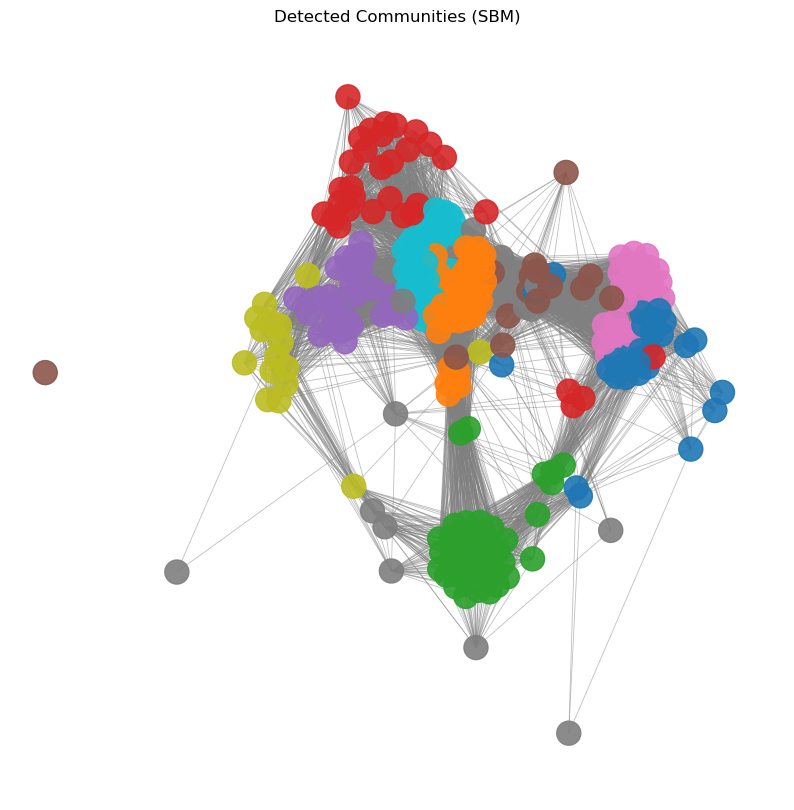

In [ ]:
import numpy as np
import pandas as pd

A = np.loadtxt("/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus/graph_adjacency.csv", delimiter=",")
assign_df = pd.read_csv("/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm/spectral_gmm_assignments.csv")
labels = assign_df["community"].values
taxa = assign_df["taxon"].values

visualize_communities(
    A,
    labels,
    taxa=taxa,
    outpath="./community_graph.png"
)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_gmm_embedding_separate_legend(
    embedding_path,
    labels_path,
    taxa_path,
    out_plot="gmm_embedding.png",
    out_legend="gmm_legend.pdf"
):

    # Load embedding and labels
    Y = np.load(embedding_path)
    labels = pd.read_csv(labels_path)["community"].values
    taxa = pd.read_csv(taxa_path, header=None)[0].tolist()

    # Use first two meaningful spectral dimensions
    U = Y[:, :2]

    unique_labels = np.unique(labels)

    # -------------------------------------------------------
    # 1. MAIN CLEAN PLOT (no legend)
    # -------------------------------------------------------
    plt.figure(figsize=(8, 6))
    for k in unique_labels:
        idx = np.where(labels == k)[0]
        plt.scatter(U[idx, 0], U[idx, 1], s=60)

    plt.xlabel("Spectral Dimension 1")
    plt.ylabel("Spectral Dimension 2")
    plt.title("Spectral Embedding (GMM Clusters)")
    plt.tight_layout()
    plt.savefig(out_plot, dpi=300)
    plt.close()

    print(f"[INFO] Main plot saved to {out_plot}")

    # -------------------------------------------------------
    # 2. SEPARATE LEGEND FIGURE (clean vector PDF)
    # -------------------------------------------------------
    fig_legend = plt.figure(figsize=(6, 10))
    ax = fig_legend.add_subplot(111)
    ax.axis("off")

    lines = []
    labels_text = []

    for k in unique_labels:
        idx = np.where(labels == k)[0]
        fake_point = ax.plot([], [], 'o')[0]  # invisible marker for legend
        lines.append(fake_point)

        # Join taxa names for that cluster
        cluster_taxa = ", ".join([taxa[i] for i in idx])
        labels_text.append(f"Cluster {k}: {cluster_taxa}")

    fig_legend.legend(lines, labels_text, loc='center left', fontsize=7)
    fig_legend.tight_layout()
    fig_legend.savefig(out_legend, dpi=300)
    plt.close(fig_legend)

    print(f"[INFO] Legend saved to {out_legend}")


In [3]:

# ---------------------------------------------------
# Example usage:
# ---------------------------------------------------

plot_gmm_embedding_separate_legend(
    "/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm/spectral_embedding.npy",
    "/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm/spectral_gmm_assignments.csv",
    "/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus/graph_taxa_index.tsv",
    out_plot="gmm_plot_clean.png",
    out_legend="gmm_legend.pdf"
)


[INFO] Main plot saved to gmm_plot_clean.png
[INFO] Legend saved to gmm_legend.pdf


In [1]:
import sys
sys.path.append("../src")   # because your notebook is inside notebooks/
from advanced_visualization import run_advanced_visualization

run_advanced_visualization(
    embedding_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm_genus/spectral_embedding.npy",
    assignments_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm_genus/spectral_gmm_assignments.csv",
    taxa_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/graph_taxa_index.tsv",
    adjacency_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/graph_adjacency.csv",
    rho_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/rho.py",
    sbm_block_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/sbm_block_P.csv"
)

[INFO] Loading core files...
[Saved] visualizations/spectral_embedding.png
[Saved] visualizations/spectral_embedding.png


/data/users3/razumah1/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Saved] visualizations/umap_embedding.png
[Saved] visualizations/spectral_vs_umap.png
[Saved] visualizations/spectral_vs_umap.png


/home/users/razumah1/Desktop/AAB Project/notebooks/../src/advanced_visualization.py:410: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[Saved] network.png


/home/users/razumah1/Desktop/AAB Project/notebooks/../src/advanced_visualization.py:424: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="tab10")


[Saved] visualizations/cluster_sizes.png
[Saved] visualizations/degree_distribution.png
[WARN] rho.npy not found; skipping correlation heatmap.
[Saved] visualizations/taxa_per_cluster.tsv
[Saved] visualizations/taxa_enrichment_summary.tsv
[Saved] visualizations/degree_distribution.png
[WARN] rho.npy not found; skipping correlation heatmap.
[Saved] visualizations/taxa_per_cluster.tsv
[Saved] visualizations/taxa_enrichment_summary.tsv
[Saved] visualizations/silhouette_scores.png
[INFO] Mean silhouette score = 0.312
[Saved] visualizations/silhouette_scores.png
[INFO] Mean silhouette score = 0.312
[Saved] visualizations/louvain_vs_gmm_confusion_counts.png
[INFO] ARI(Louvain, GMM) = 0.4284
[Saved] visualizations/louvain_vs_gmm_confusion_counts.png
[INFO] ARI(Louvain, GMM) = 0.4284
[Saved] visualizations/sbm_block_heatmap.png
[Saved] visualizations/sbm_block_heatmap.png
[Saved] visualizations/pathogens_embedding.png
[Saved] visualizations/pathogens_embedding.png
[Saved] visualizations/spectr

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Detect evidence-based pathogens (ANNOTATION)
# ----------------------------------------------------------
def is_pathogen(name):
    name = name.lower()
    keywords = [
        "klebsiella", "pseudomonas", "escherichia", "staphylococcus",
        "streptococcus", "salmonella", "shigella", "campylobacter",
        "clostridium", "yersinia", "norovirus", "adenovirus",
        "influenza", "rotavirus", "sars", "cov"
    ]
    return any(k in name for k in keywords)

# ----------------------------------------------------------
# Circular Barplot (Genus-Level, Grouped by Community)
# ----------------------------------------------------------
def circular_degree_barplot(
    taxa, labels, adjacency, top_k=10, outpath="circular_degree_barplot.png"
):
    """
    A circular barplot of nodal degree grouped by community.

    taxa: list of genus names
    labels: cluster assignments
    adjacency: adjacency matrix A
    """
    df = pd.DataFrame({
        "taxon": taxa,
        "cluster": labels,
        "degree": adjacency.sum(axis=1)
    })

    # Sort by cluster then degree (descending)
    df = df.sort_values(["cluster", "degree"], ascending=[True, False])

    # Restrict to top K per community
    df_top = (
        df.groupby("cluster")
          .head(top_k)
          .reset_index(drop=True)
    )

    N = len(df_top)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)

    # Colors for clusters
    unique_clusters = sorted(df_top["cluster"].unique())
    cmap = plt.get_cmap("tab20")
    color_map = {c: cmap(c % 20) for c in unique_clusters}

    bar_colors = df_top["cluster"].map(color_map).values
    degrees = df_top["degree"].values

    # Normalize degree height
    heights = degrees / degrees.max() * 1.0

    fig = plt.figure(figsize=(14, 14))
    ax = plt.subplot(111, polar=True)

    # Plot bars
    ax.bar(
        angles,
        heights,
        width=2*np.pi/N,
        color=bar_colors,
        alpha=0.85
    )

    # Label each bar
    for angle, h, (_, row) in zip(angles, heights, df_top.iterrows()):
        label = row["taxon"]
        color = "crimson" if is_pathogen(label) else "black"

        ax.text(
            angle,
            h + 0.05,
            label,
            rotation=np.degrees(angle),
            rotation_mode="anchor",
            ha="center",
            va="center",
            fontsize=8,
            color=color,
            fontweight="bold" if is_pathogen(label) else "normal"
        )

    # Title
    plt.title(
        "Circular Barplot of Nodal Degree by Community (Genus Level)",
        fontsize=18,
        pad=20
    )

    # Remove radial ticks
    ax.set_yticklabels([])
    ax.grid(False)

    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.show()

    print(f"[Saved] {outpath}")


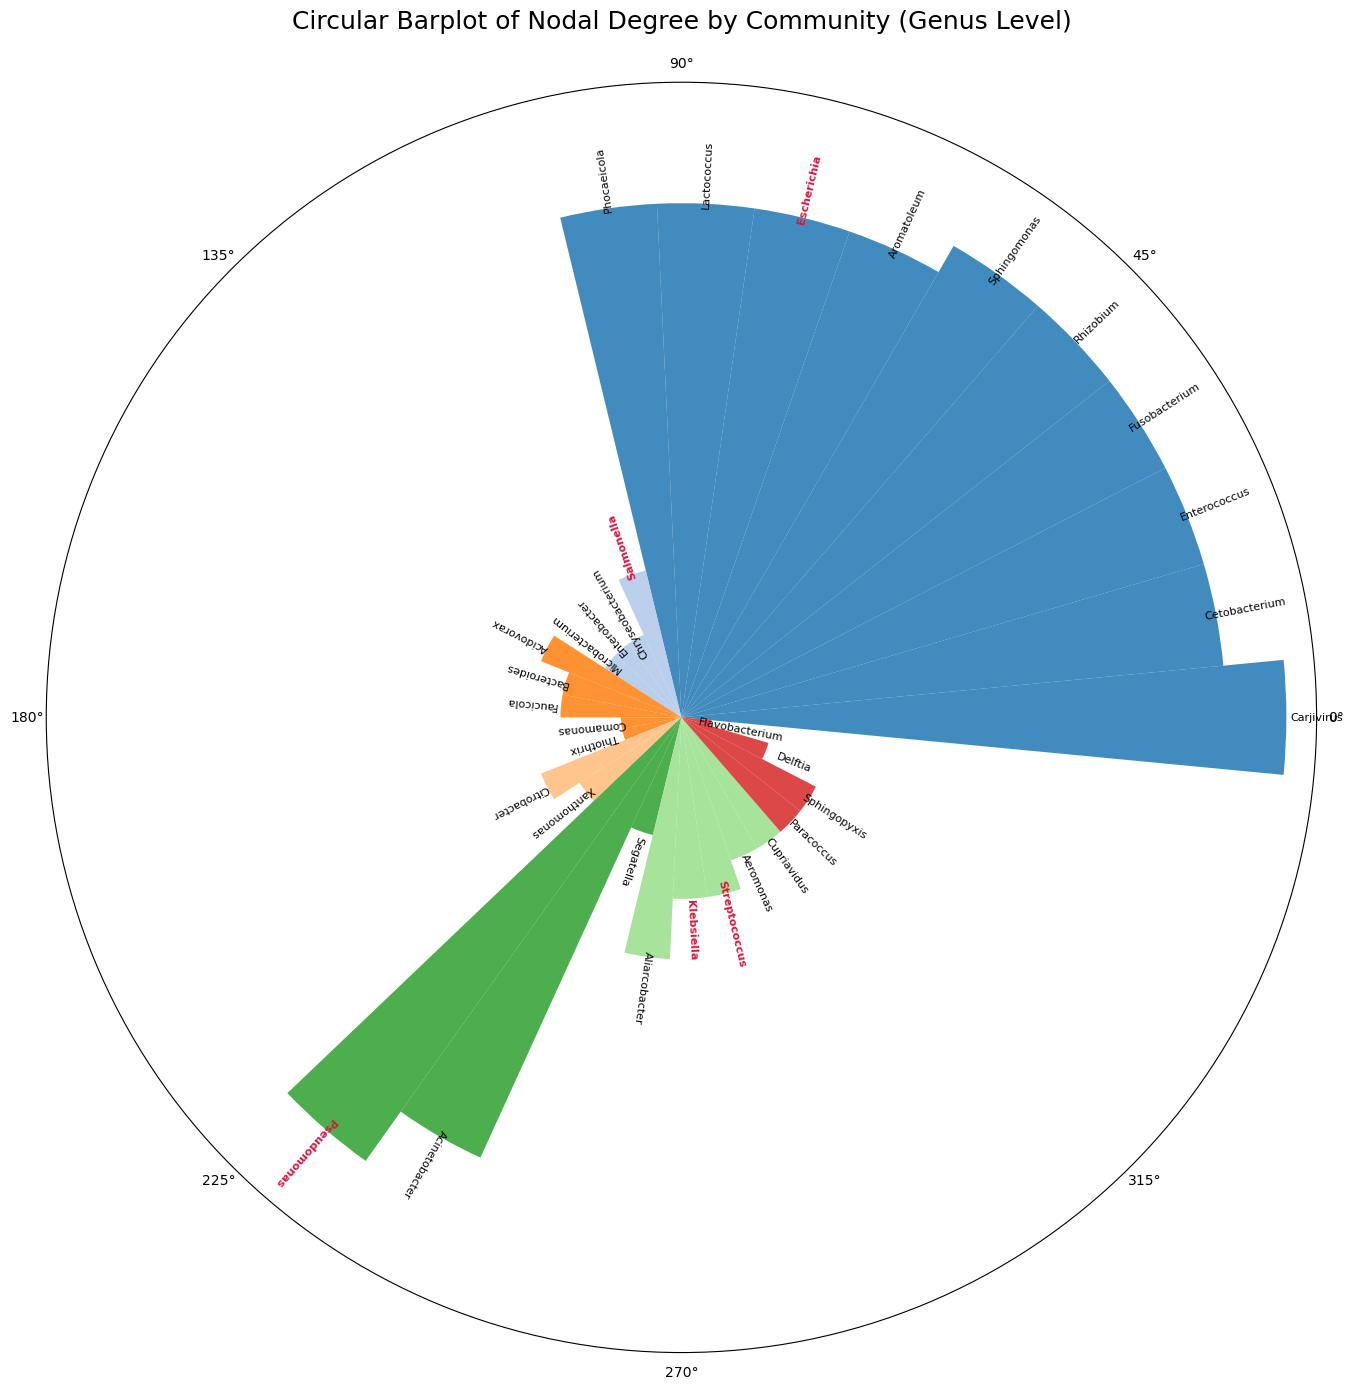

[Saved] circular_degree_barplot.png


In [40]:
A = np.loadtxt("/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/graph_adjacency.csv", delimiter=",")
assign_df = pd.read_csv("/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm_genus/spectral_gmm_assignments.csv")

taxa = assign_df["taxon"].values
labels = assign_df["community"].values

circular_degree_barplot(
    taxa,
    labels,
    adjacency=A,
    top_k=10
)


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
#     FINAL COMBINED WILEY-STYLE CIRCULAR DEGREE PLOT
# ------------------------------------------------------------
def wiley_circular_plot_final(
    taxa,
    labels,
    adjacency,
    outpath="wiley_circular_degree_final.png"
):
    
    taxa   = np.array(taxa)
    labels = np.array(labels)
    A      = np.asarray(adjacency)

    # ----------------------------
    # Compute degrees + metadata
    # ----------------------------
    degrees = A.sum(axis=1)

    df = pd.DataFrame({
        "genus": taxa,
        "cluster": labels,
        "deg": degrees
    })

    # Sort within clusters by degree (descending)
    df = df.sort_values(["cluster", "deg"], ascending=[True, False]).reset_index(drop=True)

    n = len(df)
    unique_clusters = sorted(df["cluster"].unique())
    K = len(unique_clusters)

    # angle for each bar
    df["angle"] = np.linspace(0, 2*np.pi, n, endpoint=False)
    max_deg = df["deg"].max()
    df["height"] = 0.65 * (df["deg"] / max_deg)

    # cluster colors
    cmap = plt.get_cmap("tab10")
    cluster_colors = {c: cmap(c % 10) for c in unique_clusters}

    # ----------------------------
    # Setup Figure
    # ----------------------------
    fig = plt.figure(figsize=(14, 14))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.grid(False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.spines["polar"].set_visible(False)

    # radii
    bar_bottom = 0.25
    arc_bottom = 0.15
    arc_top    = 0.80
    bar_width  = 2*np.pi / n * 0.9
    delta      = (2*np.pi / n) * 0.5

    # ----------------------------
    # Draw Cluster Arcs
    # ----------------------------
    for c in unique_clusters:
        sub = df[df["cluster"] == c]
        if sub.empty:
            continue

        start = sub["angle"].min() - delta
        end   = sub["angle"].max() + delta
        width = end - start
        center = start + width/2

        ax.bar(
            center,
            arc_top - arc_bottom,
            width=width,
            bottom=arc_bottom,
            color=cluster_colors[c],
            alpha=0.25,
            edgecolor="none",
            zorder=0
        )

    # ----------------------------
    # Draw Bars
    # ----------------------------
    for _, row in df.iterrows():
        ax.bar(
            row["angle"],
            row["height"],
            width=bar_width,
            bottom=bar_bottom,
            color=cluster_colors[row["cluster"]],
            edgecolor="none",
            alpha=0.90,
            zorder=2
        )

    # ------------------------------------------------------
    # WILEY-STYLE BAR LABELS (vertical, outward-facing)
    # ------------------------------------------------------
    for _, row in df.iterrows():
        angle   = row["angle"]
        genus   = row["genus"]
        h       = row["height"]

        # label placed right above bar tip
        r_label = bar_bottom + h + 0.04

        # angle in degrees
        ang_deg = np.degrees(angle)

        # ---------- Outward vertical text logic ----------
        # Right half of circle: (−90° to +90°)
        if -90 <= ang_deg <= 90:
            rotation = ang_deg + 90
            va = "bottom"
        else:
            # Left half → flip text so it is readable
            rotation = ang_deg - 90
            va = "top"

        ax.text(
            angle,
            r_label,
            genus,
            fontsize=8,
            rotation=rotation,
            rotation_mode="anchor",
            ha="center",
            va=va,
            color="black"
        )


    # ----------------------------
    # Horizontal Community Names
    # ----------------------------
        # ------------------------------------------------------
    # COMMUNITY LABELS + TOP TWO TAXA (bulleted list)
    # ------------------------------------------------------
    for c in unique_clusters:

        sub = df[df["cluster"] == c]

        # midpoint angle of cluster arc
        theta_mid = 0.5 * (sub["angle"].min() + sub["angle"].max())

        # Determine top two genera by degree
        top_two = list(sub.sort_values("deg", ascending=False)["genus"].head(2))

        # Main label (dominant genus community)
        main_label = f"{top_two[0]} Community"

        # Bullet points
        bullets = "\n".join([f"• {g}" for g in top_two])

        # Combine with line break
        full_label = f"{main_label}\n{bullets}"

        # Position OUTSIDE the circle
        ax.text(
            theta_mid,
            1.25,
            full_label,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            rotation=0
        )

        # Inner ring cluster number
        ax.text(
            theta_mid,
            0.20,
            str(c + 1),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )

    #plt.title("Circular Bar Plot of Nodal Degree by Community (Wiley-style)", fontsize=18, pad=20)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.show()

    print(f"[Saved] {outpath}")


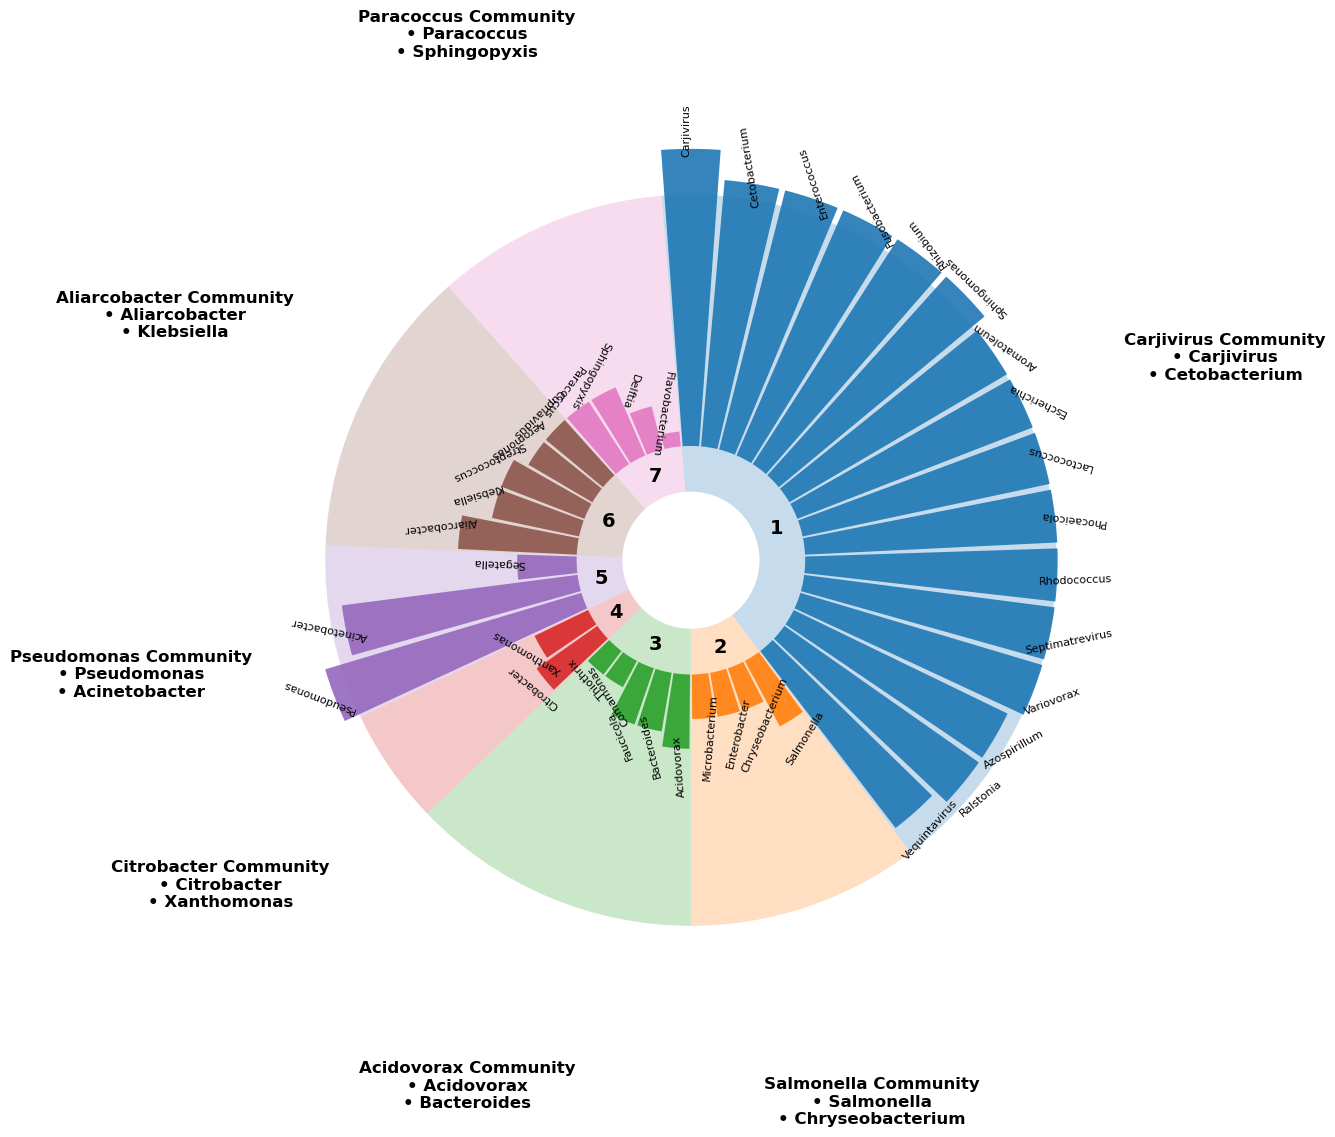

[Saved] final_wiley_plot.png


In [12]:


# Load
A = np.loadtxt(
    "/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/graph_adjacency.csv",
    delimiter=","
)

# Load GMM communities
assign_df = pd.read_csv(
    "/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm_genus/spectral_gmm_assignments.csv"
)
taxa   = assign_df["taxon"].values          # already genus names
labels = assign_df["community"].values      # cluster IDs

# Run plot
wiley_circular_plot_final(
    taxa=taxa,
    labels=labels,
    adjacency=A,
    outpath="final_wiley_plot.png"
)


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def wiley_style_circular_degree_plot_v2(
    taxa,
    labels,
    adjacency,
    outpath="wiley_circular_degree_v2.png",
    max_clusters=10
):
    taxa   = np.array(taxa)
    labels = np.array(labels)
    A      = np.asarray(adjacency)

    degrees = A.sum(axis=1)
    
    unique_clusters = np.unique(labels)
    cluster_to_idx = {c: i for i, c in enumerate(unique_clusters)}
    cluster_ids = np.array([cluster_to_idx[c] for c in labels])
    K = len(unique_clusters)

    df = pd.DataFrame({
        "genus": taxa,
        "cluster": cluster_ids,
        "deg": degrees
    })

    df = df.sort_values(["cluster", "deg"], ascending=[True, False]).reset_index(drop=True)
    n = len(df)

    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    df["angle"] = angles

    max_deg = df["deg"].max()
    df["height"] = 0.65 * (df["deg"] / max_deg)

    cmap = plt.get_cmap("tab10")
    cluster_colors = {k: cmap(k % 10) for k in range(min(K, 10))}

    fig = plt.figure(figsize=(14, 14))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.grid(False)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.spines["polar"].set_visible(False)

    bar_bottom = 0.25
    arc_bottom = 0.15
    arc_top    = 0.80
    bar_width  = 2*np.pi / n * 0.9

    delta = (2*np.pi / n) * 0.5

    # ---- Draw background arcs per cluster ----
    for k in range(K):
        sub = df[df["cluster"] == k]
        if sub.empty:
            continue
        angles_k = sub["angle"].values
        theta_start = angles_k.min() - delta
        theta_end   = angles_k.max() + delta
        theta_center = 0.5*(theta_start + theta_end)
        theta_width  = (theta_end - theta_start)

        ax.bar(
            theta_center,
            arc_top - arc_bottom,
            width=theta_width,
            bottom=arc_bottom,
            color=cluster_colors[k],
            alpha=0.25,
            edgecolor="none",
            zorder=0
        )

    # ---- Draw bars ----
    for _, row in df.iterrows():
        k = row["cluster"]
        angle = row["angle"]
        height = row["height"]

        ax.bar(
            angle,
            height,
            width=bar_width,
            bottom=bar_bottom,
            color=cluster_colors[k],
            alpha=0.85,
            edgecolor="none",
            zorder=2
        )

    # ---- Vertical Text Labels ----
    for _, row in df.iterrows():
        angle = row["angle"]
        genus = row["genus"]
        r_label = 0.92

        # compute angle to control text flip
        rotation = np.degrees(angle)
        if rotation > 90 and rotation < 270:
            rotation += 180
            ha = "right"
        else:
            ha = "left"

        ax.text(
            angle,
            r_label,
            genus,
            rotation=rotation,
            ha=ha,
            va="center",
            fontsize=8,
            rotation_mode="anchor"
        )

    # ---- Horizontal Community Labels ----
    for k in range(K):
        sub = df[df["cluster"] == k]
        angles_k = sub["angle"].values
        theta_mid = 0.5*(angles_k.min() + angles_k.max())

        dominant_genus = sub.iloc[0]["genus"]
        comm_name = f"{dominant_genus} Community"

        x = np.cos(theta_mid) * 1.2
        y = np.sin(theta_mid) * 1.2

        ax.text(
            theta_mid,
            1.20,
            comm_name,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            rotation=0   # horizontal
        )

        # ---- Cluster Number in Inner Ring ----
        ax.text(
            theta_mid,
            0.20,
            str(k+1),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )

    plt.title("Circular Bar Plot of Nodal Degree by Community (Wiley-style)", fontsize=18, pad=20)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300, transparent=True)
    plt.show()
    print(f"[Saved] {outpath}")


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
#   EXHAUSTIVE BIOLOGICAL SIGNATURE DICTIONARIES
# ------------------------------------------------------------

# Human gut microbiome
GUT_SET = {
    "Bacteroides","Phocaeicola","Parabacteroides","Prevotella","Segatella",
    "Faecalibacterium","Agathobacter","Roseburia","Blautia","Bifidobacterium",
    "Eubacterium","Anaerostipes","Ruminococcus","Butyricicoccus","Coprococcus",
    "Subdoligranulum","Enterococcus","Escherichia","Klebsiella","Citrobacter",
    "Enterobacter","Morganella","Proteus","Serratia","Bilophila","Fusobacterium",
    "Veillonella","Eggerthella","Clostridium","Lactobacillus","Lactococcus",
    "Turicibacter","Akkermansia","Collinsella","Odoribacter","Barnesiella",
    "Alistipes","Cetobacterium"
}

# Pathogens (enteric + clinical)
PATHOGEN_SET = {
    "Salmonella","Shigella","Campylobacter","Listeria","Vibrio","Yersinia",
    "Acinetobacter","Pseudomonas","Stenotrophomonas","Staphylococcus",
    "Streptococcus","Klebsiella","Enterobacter","Citrobacter","Raoultella",
    "Morganella","Proteus","Serratia","Aeromonas","Aliarcobacter","Arcobacter",
    "Neisseria","Haemophilus","Bordetella","Mycobacterium"
}

# Environmental freshwater/soil
ENVIRONMENTAL_SET = {
    "Comamonas","Variovorax","Delftia","Cupriavidus","Flavobacterium",
    "Sphingomonas","Sphingopyxis","Paracoccus","Pseudonocardia","Rhodococcus",
    "Rhizobium","Agrobacterium","Acidovorax","Azoarcus","Azospirillum",
    "Brevundimonas","Hydrogenophaga","Janthinobacterium","Methylobacterium",
    "Nitrospira","Nitrosomonas","Nitrosococcus","Phenylobacterium","Gordonia"
}

# Aquatic pathogens
AQUATIC_SET = {
    "Aeromonas","Aliarcobacter","Arcobacter","Vibrio","Flavobacterium",
    "Shewanella","Plesiomonas","Photobacterium","Psychrobacter","Edwardsiella"
}

# Biofilm-associated genera
BIOFILM_SET = {
    "Thiothrix","Zoogloea","Comamonas","Delftia","Paracoccus","Sphingomonas",
    "Sphingopyxis","Gordonia","Trichococcus","Mycolicibacterium","Nocardia",
    "Brevibacterium","Nitrospira","Acidovorax"
}

# Anaerobic sludge (WWTP digesters)
SLUDGE_SET = {
    "Methanosaeta","Methanosarcina","Methanobacterium","Clostridium",
    "Bacteroides","Firmicutes","Chloroflexi","Synergistes","Desulfovibrio",
    "Syntrophomonas"
}

# Oral/nasal microbiome
ORAL_SET = {
    "Streptococcus","Haemophilus","Actinomyces","Veillonella","Prevotella",
    "Neisseria","Porphyromonas","Fusobacterium","Capnocytophaga",
    "Leptotrichia","Gemella","Granulicatella","Rothia"
}

# Skin microbiome
SKIN_SET = {
    "Staphylococcus","Corynebacterium","Cutibacterium","Micrococcus",
    "Dermacoccus","Kocuria","Propionibacterium","Brevibacterium"
}

# Hospital-associated MDR organisms
HOSPITAL_SET = {
    "Acinetobacter","Pseudomonas","Stenotrophomonas","Klebsiella",
    "Enterobacter","Morganella","Proteus","Serratia","Citrobacter",
    "Elizabethkingia","Burkholderia","Achromobacter"
}

# Nitrogen / Sulfur cycle (functional WWTP bacteria)
N_CYCLE_SET = {
    "Nitrosomonas","Nitrosospira","Nitrospira","Nitrobacter","Azoarcus",
    "Paracoccus","Alcaligenes","Thauera","Comamonas","Acidovorax",
    "Thiomicrospira","Sulfurimonas","Desulfovibrio","Beggiatoa"
}

# Fecal indicators
FECAL_SET = {
    "Escherichia","Enterococcus","Bacteroides","Clostridium",
    "Parabacteroides","Phocaeicola","Prevotella","Akkermansia"
}

# Viral/phage signatures
VIRAL_SET = {
    "Myovirus","Siphovirus","Podovirus","Vequintavirus","Septimatrevirus",
    "Carjivirus","T4virus","Lambda-like","CrAssphage","Levivirus"
}

# ------------------------------------------------------------
#   COMMUNITY LABELING FUNCTION (PRIORITY-BASED)
# ------------------------------------------------------------
def infer_community_label(genus_list):
    roots = [g.split()[0] for g in genus_list]

    scores = {
        "Pathogen-Enriched": sum(r in PATHOGEN_SET for r in roots),
        "Human Gut–Enriched": sum(r in GUT_SET for r in roots),
        "Fecal Indicator Community": sum(r in FECAL_SET for r in roots),
        "Hospital-Associated": sum(r in HOSPITAL_SET for r in roots),
        "Aquatic Pathogens": sum(r in AQUATIC_SET for r in roots),
        "Wastewater Biofilm": sum(r in BIOFILM_SET for r in roots),
        "Environmental": sum(r in ENVIRONMENTAL_SET for r in roots),
        "Oral/Nasal Microbiome": sum(r in ORAL_SET for r in roots),
        "Skin Microbiome": sum(r in SKIN_SET for r in roots),
        "Anaerobic Sludge": sum(r in SLUDGE_SET for r in roots),
        "Nitrogen/Sulfur Cycle": sum(r in N_CYCLE_SET for r in roots),
        "Viral/Phage-Enriched": sum(r in VIRAL_SET for r in roots)
    }

    # Priority: If pathogens dominate, always choose them
    if scores["Pathogen-Enriched"] >= 2:
        return "Pathogen-Enriched"

    # Otherwise, pick highest score
    label, max_score = max(scores.items(), key=lambda x: x[1])
    return label if max_score > 0 else "Mixed Community"


# ------------------------------------------------------------
#   FINAL COMBINED WILEY-STYLE CIRCULAR PLOT
# ------------------------------------------------------------
def wiley_circular_plot_final(
    taxa,
    labels,
    adjacency,
    outpath="wiley_circular_degree_final.png"
):
    
    taxa   = np.array(taxa)
    labels = np.array(labels)
    A      = np.asarray(adjacency)

    degrees = A.sum(axis=1)

    df = pd.DataFrame({
        "genus": taxa,
        "cluster": labels,
        "deg": degrees
    })

    df = df.sort_values(["cluster", "deg"], ascending=[True, False]).reset_index(drop=True)

    n = len(df)
    unique_clusters = sorted(df["cluster"].unique())

    df["angle"] = np.linspace(0, 2*np.pi, n, endpoint=False)
    max_deg = df["deg"].max()
    df["height"] = 0.65 * (df["deg"] / max_deg)

    cmap = plt.get_cmap("tab10")
    cluster_colors = {c: cmap(c % 10) for c in unique_clusters}

    fig = plt.figure(figsize=(14, 14))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.grid(False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.spines["polar"].set_visible(False)

    bar_bottom = 0.25
    arc_bottom = 0.15
    arc_top    = 0.80
    bar_width  = 2*np.pi / n * 0.9
    delta      = (2*np.pi / n) * 0.5

    # Draw Cluster Arcs
    for c in unique_clusters:
        sub = df[df["cluster"] == c]
        if sub.empty: continue

        start = sub["angle"].min() - delta
        end   = sub["angle"].max() + delta
        width = end - start
        center = start + width/2

        ax.bar(
            center,
            arc_top - arc_bottom,
            width=width,
            bottom=arc_bottom,
            color=cluster_colors[c],
            alpha=0.25,
            edgecolor="none",
            zorder=0
        )

    # Draw Bars
    for _, row in df.iterrows():
        ax.bar(
            row["angle"],
            row["height"],
            width=bar_width,
            bottom=bar_bottom,
            color=cluster_colors[row["cluster"]],
            edgecolor="none",
            alpha=0.90,
            zorder=2
        )

    # Wiley-style vertical Bar Labels (aligned above each bar, always vertical outward)
for _, row in df.iterrows():
    angle = row["angle"]
    genus = row["genus"]
    h = row["height"]
    
    # Position the label directly above the bar
    # Slight offset to sit on top of bar
    r_label = bar_bottom + h + 0.08
    
    # Determine if this is left side or right side of circle
    # Convert angle to 0-360 range for easier logic
    angle_deg = angle % (2*np.pi)
    
    # For LEFT side (angles between 90-270 degrees)
    if np.pi/2 <= angle_deg <= 3*np.pi/2:
        # Left side: rotate text -90° (vertical, reading upward from left)
        rotation = -90
        va = "bottom"  # Anchor at bottom for upward reading
    else:
        # Right side: rotate text +90° (vertical, reading downward from right)
        rotation = 90
        va = "top"     # Anchor at top for downward reading
    
    ax.text(
        angle,
        r_label,
        genus,
        rotation=rotation,
        ha="center",
        va=va,
        fontsize=8,
        color="black",
        rotation_mode="anchor"
    )

    # Dynamic Wiley-style Community Labels
    for c in unique_clusters:

        sub = df[df["cluster"] == c]
        theta_mid = 0.5 * (sub["angle"].min() + sub["angle"].max())

        genera_in_cluster = sub["genus"].tolist()
        name = infer_community_label(genera_in_cluster)

        ax.text(
            theta_mid,
            1.20,
            name,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            rotation=0
        )

        ax.text(
            theta_mid,
            0.20,
            str(c + 1),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )

    plt.title("Circular Bar Plot of Nodal Degree by Community (Wiley-style)", fontsize=18, pad=20)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.show()

    print(f"[Saved] {outpath}")


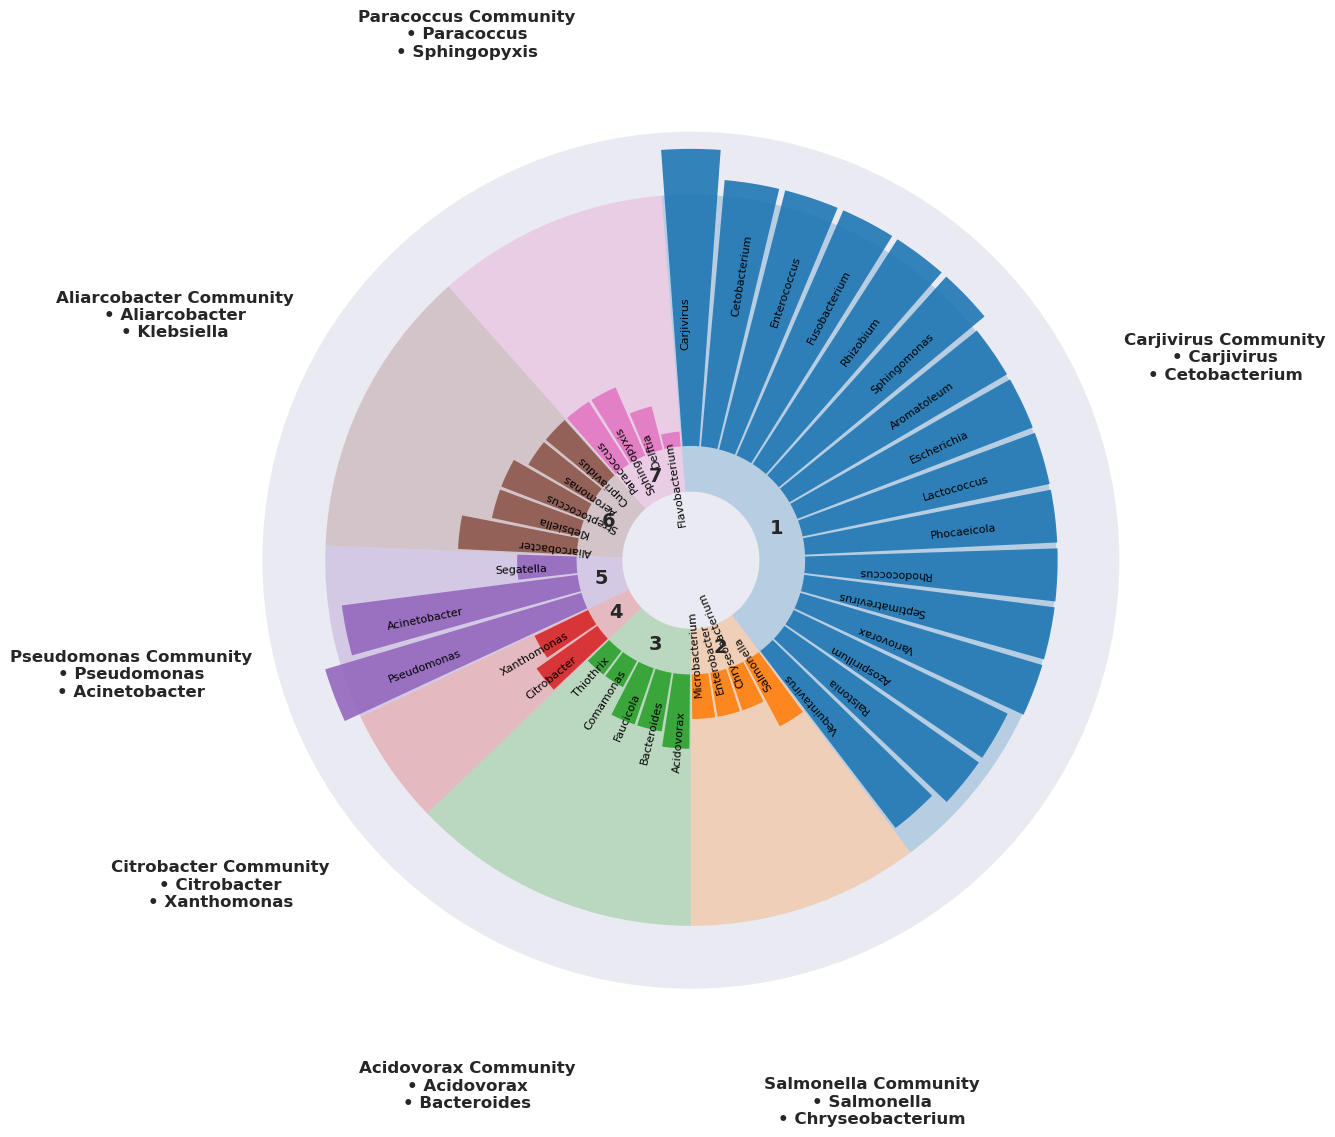

[Saved] wiley_circular_degree.png


,genus,cluster,deg,angle,height
0,Carjivirus,0,20.0,0.000000,0.6500
1,Cetobacterium,0,18.0,0.161107,0.5850
2,Enterococcus,0,18.0,0.322215,0.5850
3,Fusobacterium,0,18.0,0.483322,0.5850
4,Rhizobium,0,18.0,0.644429,0.5850
5,Sphingomonas,0,18.0,0.805537,0.5850
6,Aromatoleum,0,17.0,0.966644,0.5525
7,Escherichia,0,17.0,1.127751,0.5525
8,Lactococcus,0,17.0,1.288859,0.5525
9,Phocaeicola,0,17.0,1.449966,0.5525


In [17]:
# Load adjacency (n x n)
A = np.loadtxt(
    "/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/graph_adjacency.csv",
    delimiter=","
)

# Load GMM communities
assign_df = pd.read_csv(
    "/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm_genus/spectral_gmm_assignments.csv"
)
taxa   = assign_df["taxon"].values          # already genus names
labels = assign_df["community"].values      # cluster IDs

wiley_circular_plot_final(
    taxa=taxa,
    labels=labels,
    adjacency=A,
    outpath="wiley_circular_degree.png"
)


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
#     FINAL COMBINED WILEY-STYLE CIRCULAR DEGREE PLOT
# ------------------------------------------------------------
def wiley_circular_plot_final(
    taxa,
    labels,
    adjacency,
    outpath="wiley_circular_degree_final.png"
):
    
    taxa   = np.array(taxa)
    labels = np.array(labels)
    A      = np.asarray(adjacency)

    # ----------------------------
    # Compute degrees + metadata
    # ----------------------------
    degrees = A.sum(axis=1)

    df = pd.DataFrame({
        "genus": taxa,
        "cluster": labels,
        "deg": degrees
    })

    # Sort within clusters by degree (descending)
    df = df.sort_values(["cluster", "deg"], ascending=[True, False]).reset_index(drop=True)

    n = len(df)
    unique_clusters = sorted(df["cluster"].unique())
    K = len(unique_clusters)

    # angle for each bar
    df["angle"] = np.linspace(0, 2*np.pi, n, endpoint=False)
    max_deg = df["deg"].max()
    df["height"] = 0.65 * (df["deg"] / max_deg)

    # cluster colors
    cmap = plt.get_cmap("tab10")
    cluster_colors = {c: cmap(c % 10) for c in unique_clusters}

    # ----------------------------
    # Setup Figure
    # ----------------------------
    fig = plt.figure(figsize=(14, 14))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.grid(False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.spines["polar"].set_visible(False)

    # radii
    bar_bottom = 0.25
    arc_bottom = 0.15
    arc_top    = 0.80
    bar_width  = 2*np.pi / n * 0.9
    delta      = (2*np.pi / n) * 0.5

    # ----------------------------
    # Draw Cluster Arcs
    # ----------------------------
    for c in unique_clusters:
        sub = df[df["cluster"] == c]
        if sub.empty:
            continue

        start = sub["angle"].min() - delta
        end   = sub["angle"].max() + delta
        width = end - start
        center = start + width/2

        ax.bar(
            center,
            arc_top - arc_bottom,
            width=width,
            bottom=arc_bottom,
            color=cluster_colors[c],
            alpha=0.25,
            edgecolor="none",
            zorder=0
        )

    # ----------------------------
    # Draw Bars
    # ----------------------------
    for _, row in df.iterrows():
        ax.bar(
            row["angle"],
            row["height"],
            width=bar_width,
            bottom=bar_bottom,
            color=cluster_colors[row["cluster"]],
            edgecolor="none",
            alpha=0.90,
            zorder=2
        )

    # ------------------------------------------------------
    # MODIFIED: BAR LABELS EXACTLY ON TOP OF BARS
    # ------------------------------------------------------
    for _, row in df.iterrows():
        angle   = row["angle"]
        genus   = row["genus"]
        h       = row["height"]
        
        # Position label EXACTLY on top of the bar
        bar_top = bar_bottom + h
        r_label = bar_top  # No offset - directly on top
        
        # Convert angle to degrees
        ang_deg = np.degrees(angle)
        
        # Simpler approach: Just check if we're on left or right side
        # With theta_offset=pi/2 and theta_direction=-1:
        # - angle=0 is at top (12 o'clock)
        # - angle increases clockwise
        
        # Get the actual display angle after transformations
        display_angle = (450 - ang_deg) % 360  # Adjust for polar settings
        
        # Determine if we're on left or right side
        if 0 <= display_angle < 180:
            # Right side of circle
            rotation = display_angle
            va = "bottom"  # Text sits on top of bar
        else:
            # Left side of circle
            rotation = display_angle - 180
            va = "top"  # Text hangs from top of bar
        
        # Simple horizontal alignment
        if 0 <= display_angle < 180:
            ha = "center"
        else:
            ha = "center"
        
        # For better readability, we can slightly adjust position
        # Add small outward shift for labels on very short bars
        if h < 0.1:
            # For very short bars, shift label outward slightly
            outward_shift = 0.015
            r_label = bar_top + outward_shift
        
        # Set font properties
        fontsize = 8
        if len(genus) > 12:  # Longer genus names
            fontsize = 7
        
        ax.text(
            angle,
            r_label,
            genus,
            fontsize=fontsize,
            rotation=rotation,
            rotation_mode="anchor",
            ha=ha,
            va=va,
            color="black",
            fontweight="medium",
            zorder=3,
            bbox=dict(boxstyle="round,pad=0.1", 
                     facecolor="white", 
                     edgecolor="none",
                     alpha=0.7)  # Optional white background for readability
        )

    # ------------------------------------------------------
    # COMMUNITY LABELS + TOP TWO TAXA (bulleted list)
    # ------------------------------------------------------
    for c in unique_clusters:
        sub = df[df["cluster"] == c]

        # midpoint angle of cluster arc
        theta_mid = 0.5 * (sub["angle"].min() + sub["angle"].max())

        # Determine top two genera by degree
        top_two = list(sub.sort_values("deg", ascending=False)["genus"].head(2))

        # Main label (dominant genus community)
        main_label = f"{top_two[0]} Community"

        # Bullet points
        bullets = "\n".join([f"• {g}" for g in top_two])

        # Combine with line break
        full_label = f"{main_label}\n{bullets}"

        # Position OUTSIDE the circle
        ax.text(
            theta_mid,
            1.25,
            full_label,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            rotation=0
        )

        # Inner ring cluster number
        ax.text(
            theta_mid,
            0.20,
            str(c + 1),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.show()

    print(f"[Saved] {outpath}")
    return df

In [2]:
# Load adjacency (n x n)
A = np.loadtxt(
    "/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/graph_adjacency.csv",
    delimiter=","
)

# Load GMM communities
assign_df = pd.read_csv(
    "/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm_genus/spectral_gmm_assignments.csv"
)
taxa   = assign_df["taxon"].values          # already genus names
labels = assign_df["community"].values      # cluster IDs

wiley_circular_plot_final(
    taxa=taxa,
    labels=labels,
    adjacency=A,
    outpath="wiley_circular_degree.png"
)

NameError: name 'np' is not defined

In [1]:
import sys
sys.path.append("../src")   # folder containing advanced_visualization.py

from advanced_visualization_v2 import run_advanced_visualization

run_advanced_visualization(
    embedding_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm_genus/spectral_embedding.npy",
    assignments_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/ggm_genus/spectral_gmm_assignments.csv",
    taxa_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/graph_taxa_index.tsv",
    adjacency_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/graph_adjacency.csv",
    rho_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/rho.npy",
    sbm_block_path="/home/users/razumah1/Desktop/AAB Project/results/project_out/pipeline_results_genus_fixed/sbm_block_P.csv",
    outdir="visualizations_genus"
)

[INFO] Loading core files...
[Saved] visualizations_genus/spectral_embedding.png
[Saved] visualizations_genus/spectral_embedding.png


/data/users3/razumah1/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Saved] visualizations_genus/umap_embedding.png
[Saved] visualizations_genus/spectral_vs_umap.png
[Saved] visualizations_genus/spectral_vs_umap.png


/home/users/razumah1/Desktop/AAB Project/notebooks/../src/advanced_visualization_v2.py:334: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[Saved] visualizations_genus/network_graph.png
[Saved] visualizations_genus/wiley_circular_biological.png
[Saved] visualizations_genus/wiley_circular_biological.png


/home/users/razumah1/Desktop/AAB Project/notebooks/../src/advanced_visualization_v2.py:555: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="tab10")


[Saved] visualizations_genus/cluster_sizes.png
[Saved] visualizations_genus/degree_distribution.png
[Saved] visualizations_genus/degree_distribution.png
[Saved] visualizations_genus/sorted_correlation_heatmap.png
[Saved] visualizations_genus/taxa_per_cluster.tsv
[Saved] visualizations_genus/taxa_enrichment_summary.tsv
[Saved] visualizations_genus/sorted_correlation_heatmap.png
[Saved] visualizations_genus/taxa_per_cluster.tsv
[Saved] visualizations_genus/taxa_enrichment_summary.tsv
[Saved] visualizations_genus/silhouette_scores.png
[INFO] Mean silhouette score = 0.312
[Saved] visualizations_genus/silhouette_scores.png
[INFO] Mean silhouette score = 0.312
[Saved] visualizations_genus/louvain_vs_gmm_confusion_counts.png
[INFO] ARI(Louvain, GMM) = 0.4284
[Saved] visualizations_genus/louvain_vs_gmm_confusion_counts.png
[INFO] ARI(Louvain, GMM) = 0.4284
[Saved] visualizations_genus/sbm_block_heatmap.png
[Saved] visualizations_genus/sbm_block_heatmap.png
[Saved] visualizations_genus/pathogen